# Phase 2: Part Extraction & Analysis Pipeline

This notebook walks through the complete Phase 2 pipeline step-by-step:
1. **Part Extraction** - Extract slots, attention maps, and masks from trained model
2. **Clustering** - Cluster parts with optimal K selection
3. **Visualization** - View results inline
4. **Analysis** - Generate interpretability reports

Each step can be run independently by executing the corresponding cell.

---
## Setup & Imports

In [1]:
# Import dependencies
# auto reload modules
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from tqdm import tqdm

# Import backend modules
from src.data.loaders import create_dataloaders
from src.models.backbone import ResNetBackbone
from src.models.part_discovery.slot_attention import SlotAttentionModel
from src.clustering.cluster import (
    determine_optimal_k,
    plot_clustering_metrics,
    cluster_parts_per_class,
    visualize_cluster_samples_high_res,
    cluster_parts,
    visualize_clusters_tsne,
    analyze_cluster_class_correlation,
    visualize_clusters_by_class
)
from src.utils import load_config, get_device, set_seed, load_checkpoint
from experiments.cluster_parts import flatten_slots_for_clustering

# Set plotting style
plt.style.use('default')
sns.set_palette('husl')

print("✓ Imports successful")

✓ Imports successful


In [2]:
# Train Part Discovery Model
# We re-train the model with the new stable configuration (frozen backbone, 6 slots)
print("Starting Model Training... (This may take a while)")
!python ../experiments/train_part_discovery.py
print("Training Completed!")

Starting Model Training... (This may take a while)
Traceback (most recent call last):
  File "/Users/dev/ml-projects/unsupervised-parts-discovery/notebooks/../experiments/train_part_discovery.py", line 10, in <module>
    from src.data.loaders import create_dataloaders
ModuleNotFoundError: No module named 'src'
Training Completed!


---
## Configuration

In [3]:
# Load configurations
data_config = load_config('../configs/data_config.yaml')
model_config = load_config('../configs/model_config.yaml')

# Set seed for reproducibility
set_seed(data_config.get('seed', 42))

# Get device
device = get_device(model_config.get('device', 'auto'))

# Display config
print(f"Device: {device}")
print(f"Classes: {data_config['dataset']['classes']}")
print(f"Number of slots: {model_config['slot_attention']['num_slots']}")
print(f"Slot dimension: {model_config['slot_attention']['slot_dim']}")

Using mps device
Device: mps
Classes: ['airplane', 'cat', 'dog']
Number of slots: 6
Slot dimension: 128


---
## Step 1: Part Extraction

Extract slots, attention weights, and masks from the trained Slot Attention model.

In [4]:
# Configuration for extraction
CHECKPOINT_PATH = '../checkpoints/part_discovery/best_model.pt'
PARTS_OUTPUT_DIR = '../parts/extracted'
LIMIT_IMAGES = None  # Set to a number (e.g., 100) for quick testing

print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Output directory: {PARTS_OUTPUT_DIR}")
print(f"Limit: {LIMIT_IMAGES if LIMIT_IMAGES else 'All images'}")

Checkpoint: ../checkpoints/part_discovery/best_model.pt
Output directory: ../parts/extracted
Limit: All images


In [5]:
# Create dataloaders
print("Loading dataset...")
train_loader, _ = create_dataloaders(
    data_config['dataset'],
    data_config['augmentation'],
    data_config['dataloader']
)

print(f"Train set: {len(train_loader.dataset)} images")
print(f"Batch size: {train_loader.batch_size}")

Loading dataset...
Found 1200 images across 3 classes
  - airplane: 400 images
  - cat: 400 images
  - dog: 400 images
Found 300 images across 3 classes
  - airplane: 100 images
  - cat: 100 images
  - dog: 100 images

Dataset splits:
  Training: 1200 images
  Validation: 300 images
Train set: 1200 images
Batch size: 16


In [6]:
# Load models
print("Initializing models...")
backbone = ResNetBackbone.from_config(model_config['backbone'])
slot_model = SlotAttentionModel.from_config(model_config)

# Load checkpoint
print(f"\nLoading checkpoint: {CHECKPOINT_PATH}")
model_dict = torch.nn.ModuleDict({
    'backbone': backbone,
    'slot_model': slot_model
})
checkpoint = load_checkpoint(CHECKPOINT_PATH, model_dict, device=device)

# Move to device and set to eval mode
backbone.to(device)
slot_model.to(device)
backbone.eval()
slot_model.eval()

print("✓ Models loaded and ready")

Initializing models...
Frozen early layers (conv1, bn1, layer1, layer2)
ResNetBackbone initialized with pretrained weights
Output feature dimension: 2048
SlotAttentionModel initialized with 6 slots

Loading checkpoint: ../checkpoints/part_discovery/best_model.pt
Checkpoint not found at ../checkpoints/part_discovery/best_model.pt. Starting from scratch.
✓ Models loaded and ready


In [7]:
# Extract parts from all images
print("Extracting parts from images...\n")

all_slots = []
all_attn_weights = []
all_masks = []
all_image_ids = []
all_labels = []
all_images = []

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(tqdm(train_loader)):
        if LIMIT_IMAGES and batch_idx * train_loader.batch_size >= LIMIT_IMAGES:
            break
        
        images = images.to(device)
        # Store original images
        all_images.append(images.cpu())
        
        # Forward pass
        features = backbone.get_feature_maps(images)
        recon, masks, slots, attn = slot_model(features)
        
        # Store results
        all_slots.append(slots.cpu().numpy())
        all_attn_weights.append(attn.cpu().numpy())
        all_masks.append(masks.cpu().numpy())
        all_labels.extend(labels.numpy().tolist())
        
        start_id = batch_idx * train_loader.batch_size
        batch_size = images.size(0)
        all_image_ids.extend(range(start_id, start_id + batch_size))

# Concatenate results
parts_data = {
    'slots': np.concatenate(all_slots, axis=0),
    'attention_weights': np.concatenate(all_attn_weights, axis=0),
    'masks': np.concatenate(all_masks, axis=0),
    'image_ids': np.array(all_image_ids),
    'labels': np.array(all_labels)
}

print(f"\n✓ Extraction complete!")
print(f"  Extracted from: {len(all_image_ids)} images")
print(f"  Slots shape: {parts_data['slots'].shape}")
print(f"  Masks shape: {parts_data['masks'].shape}")

Extracting parts from images...



100%|██████████| 75/75 [01:05<00:00,  1.15it/s]



✓ Extraction complete!
  Extracted from: 1200 images
  Slots shape: (1200, 6, 128)
  Masks shape: (1200, 6, 128, 128)


In [8]:
# Save extracted parts
from src.analysis.save_parts import save_parts_data

save_parts_data(
    parts_data=parts_data,
    output_dir=PARTS_OUTPUT_DIR,
    checkpoint=checkpoint,
    data_config=data_config,
    model_config=model_config,
    all_images=all_images
)

✓ Parts data saved to: ../parts/extracted


### Visualize Sample Extractions

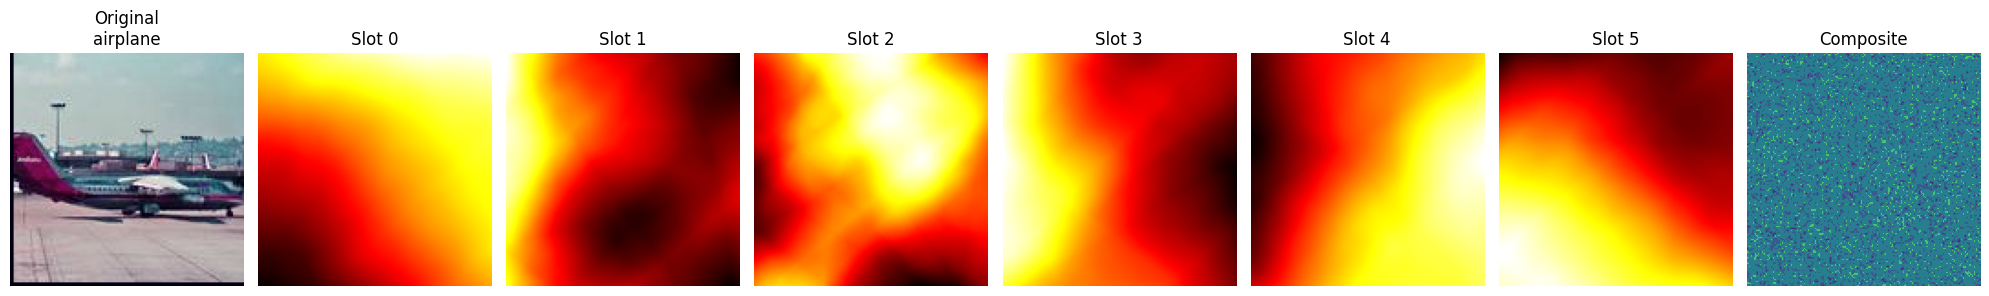

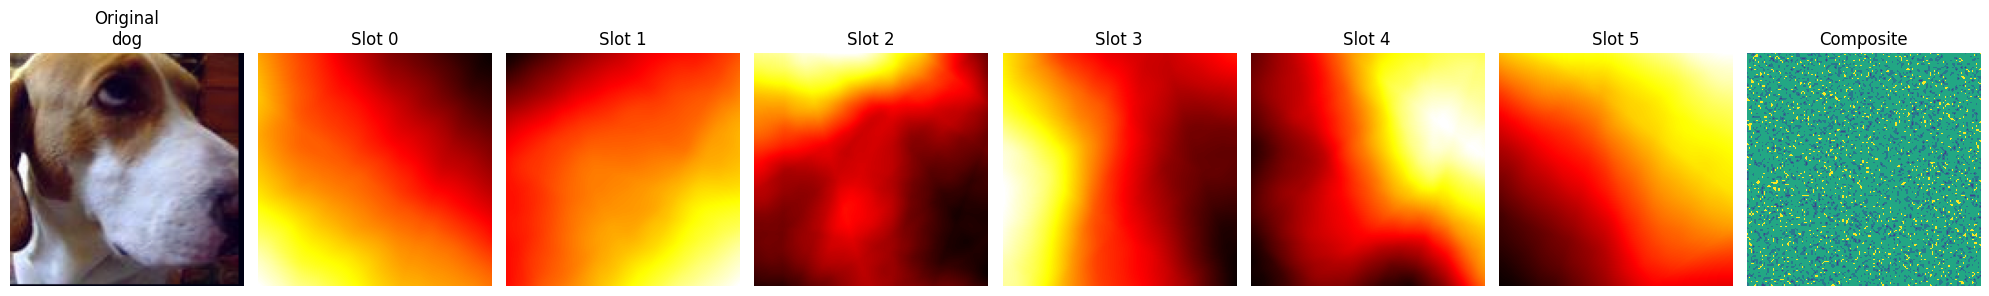

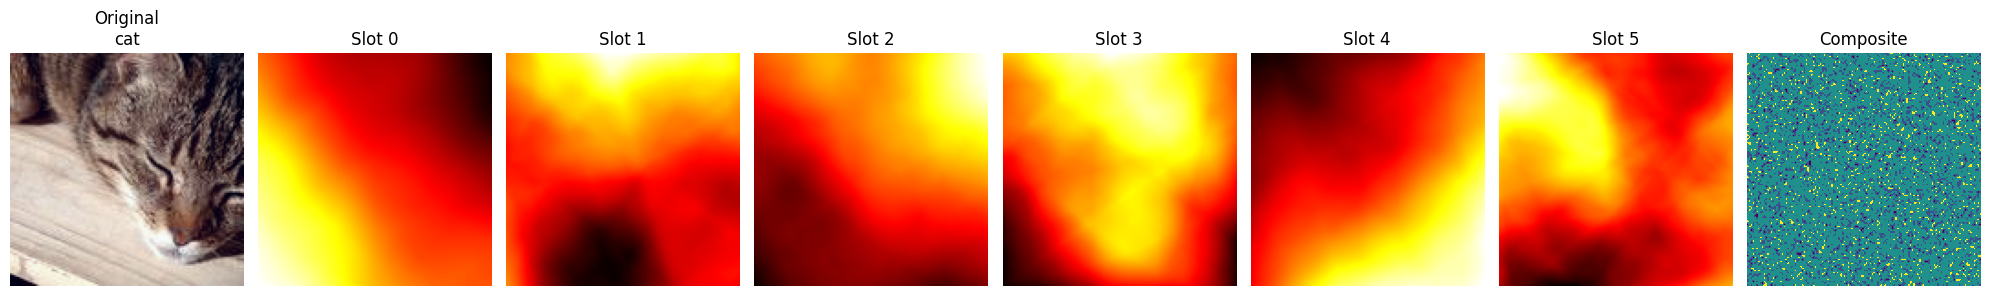


Showing attention masks for 3 sample images
Each row shows: Original image | 8 slot attention masks | Composite


In [9]:
# Visualize sample attention masks
num_samples = 3
num_slots = parts_data['masks'].shape[1]
class_names = data_config['dataset']['classes']

# Get sample images
sample_images_iter = iter(train_loader)
sample_images, sample_labels = next(sample_images_iter)

for sample_idx in range(min(num_samples, len(sample_images))):
    fig, axes = plt.subplots(1, num_slots + 2, figsize=(20, 3))
    
    # Original image
    img = sample_images[sample_idx].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    axes[0].imshow(img)
    axes[0].set_title(f'Original\n{class_names[sample_labels[sample_idx]]}')
    axes[0].axis('off')
    
    # Slot attention masks
    masks = parts_data['masks'][sample_idx]
    for slot_idx in range(num_slots):
        axes[slot_idx + 1].imshow(masks[slot_idx], cmap='hot', interpolation='bilinear')
        axes[slot_idx + 1].set_title(f'Slot {slot_idx}')
        axes[slot_idx + 1].axis('off')
    
    # Composite
    composite = masks.sum(axis=0)
    axes[-1].imshow(composite, cmap='viridis', interpolation='bilinear')
    axes[-1].set_title('Composite')
    axes[-1].axis('off')
    
    plt.tight_layout()
    plt.show()

print(f"\nShowing attention masks for {num_samples} sample images")
print("Each row shows: Original image | 8 slot attention masks | Composite")

---
## Step 2: Clustering

Cluster the extracted parts using K-means with optimal K selection.

In [10]:
# Configuration for clustering
CLUSTERS_OUTPUT_DIR = '../parts/clusters'
K_MIN = 5
K_MAX = 15
MANUAL_K = None  # Set to a number to skip optimal K selection

print(f"Clusters output: {CLUSTERS_OUTPUT_DIR}")
print(f"K range: {K_MIN} - {K_MAX}")
print(f"Manual K: {MANUAL_K if MANUAL_K else 'Auto-select'}")

Clusters output: ../parts/clusters
K range: 5 - 15
Manual K: Auto-select


In [11]:
# Flatten slots for clustering
# Each slot from each image becomes a separate part
features = flatten_slots_for_clustering(parts_data['slots'])

# Normalize features (L2 normalization)
# This is crucial for clustering embeddings, effectively using cosine similarity
print("Normalizing features (L2)...")
from sklearn.preprocessing import normalize
features = normalize(features, norm='l2', axis=1)

# Also create mapping from part index to (image_id, slot_id)
N_images, N_slots = parts_data['slots'].shape[:2]
part_to_image = np.repeat(np.arange(N_images), N_slots)
part_to_slot = np.tile(np.arange(N_slots), N_images)
part_to_class = np.repeat(parts_data['labels'], N_slots)

# Per-Class Clustering Strategy
print("\n" + "="*70)
print("PER-CLASS CLUSTERING (SELF-DETERMINATION MODE)")
print("="*70)

cluster_labels, cluster_metadata, metrics = cluster_parts_per_class(
    features=features,
    class_labels=part_to_class,
    class_names=data_config['dataset']['classes'],
    k_range=(K_MIN, K_MAX),
    n_init=20,
    random_state=42
)

# Save results
clusters_dir = Path(CLUSTERS_OUTPUT_DIR)
print(f"\nSaving clustering results to: {clusters_dir}")

np.save(clusters_dir / 'cluster_labels.npy', cluster_labels)
np.save(clusters_dir / 'cluster_centers.npy', np.zeros((1, 1))) # Placeholder as centers are per-class now

# Save metrics
with open(clusters_dir / 'clustering_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

# Save cluster metadata
def convert_numpy(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

with open(clusters_dir / 'cluster_metadata.json', 'w') as f:
    json.dump(cluster_metadata, f, indent=2, default=convert_numpy)

print(f"✓ Clustering complete!")
print(f"  Labels shape: {cluster_labels.shape}")
print(f"  Results saved to: {clusters_dir}")


Flattened slots for clustering:
  Original: 1200 images × 6 slots × 128 dims
  Flattened: 7200 total parts × 128 dims
Normalizing features (L2)...

PER-CLASS CLUSTERING (SELF-DETERMINATION MODE)

Starting Per-Class Clustering for 3 classes...
Normalizing features (L2) before clustering...

--- Processing Class: airplane (0) ---
Determining optimal K in range (5, 15)...
  K=5: Inertia=440.96, Silhouette=0.0628
  K=6: Inertia=430.87, Silhouette=0.0581
  K=7: Inertia=422.26, Silhouette=0.0588
  K=8: Inertia=413.39, Silhouette=0.0571
  K=9: Inertia=407.93, Silhouette=0.0566
  K=10: Inertia=401.57, Silhouette=0.0561
  K=11: Inertia=396.61, Silhouette=0.0542
  K=12: Inertia=392.05, Silhouette=0.0560
  K=13: Inertia=386.94, Silhouette=0.0549
  K=14: Inertia=384.46, Silhouette=0.0541
  K=15: Inertia=381.15, Silhouette=0.0517
Optimal K determined: 5 (Silhouette Score: 0.0628)
Clustering airplane parts into 5 clusters...

--- Processing Class: cat (1) ---
Determining optimal K in range (5, 15).

### Optimal K Selection

Determining optimal K...

Determining optimal K in range (5, 15)...
  K=5: Inertia=1495.35, Silhouette=0.1078
  K=6: Inertia=1459.88, Silhouette=0.0917
  K=7: Inertia=1431.63, Silhouette=0.0853
  K=8: Inertia=1409.03, Silhouette=0.0818
  K=9: Inertia=1388.85, Silhouette=0.0703
  K=10: Inertia=1369.94, Silhouette=0.0679
  K=11: Inertia=1353.37, Silhouette=0.0646
  K=12: Inertia=1337.27, Silhouette=0.0643
  K=13: Inertia=1324.84, Silhouette=0.0589
  K=14: Inertia=1311.38, Silhouette=0.0541
  K=15: Inertia=1298.73, Silhouette=0.0551
Optimal K determined: 5 (Silhouette Score: 0.1078)


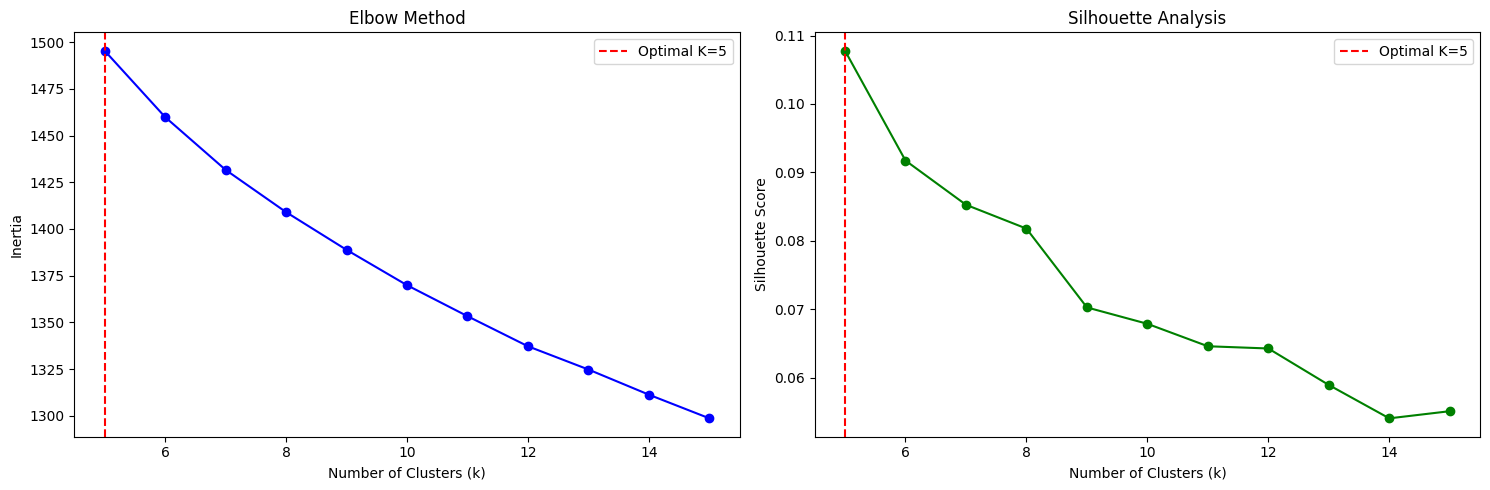

In [12]:
if MANUAL_K is None:
    print("Determining optimal K...\n")
    optimal_k, metrics = determine_optimal_k(
        features=features,
        k_range=(K_MIN, K_MAX),
        n_init=10,
        random_state=42
    )
    n_clusters = optimal_k
    
    # Plot metrics
    plot_clustering_metrics(metrics, optimal_k, save_path=None)
    plt.show()
else:
    n_clusters = MANUAL_K
    print(f"Using manual K = {n_clusters}")

### Perform Clustering

In [13]:
# Cluster the parts per class (to ensure purity)
# We use per-class clustering to guarantee that each cluster contains only one object class
cluster_labels, cluster_metadata, metrics = cluster_parts_per_class(
    features=features,
    class_labels=part_to_class,
    class_names=data_config['dataset']['classes'],
    k_range=(5, 20),
    n_init=3,
    random_state=42
)



Starting Per-Class Clustering for 3 classes...
Normalizing features (L2) before clustering...

--- Processing Class: airplane (0) ---
Determining optimal K in range (5, 20)...
  K=5: Inertia=440.96, Silhouette=0.0628
  K=6: Inertia=430.87, Silhouette=0.0581
  K=7: Inertia=422.26, Silhouette=0.0588
  K=8: Inertia=413.39, Silhouette=0.0571
  K=9: Inertia=407.93, Silhouette=0.0566
  K=10: Inertia=401.57, Silhouette=0.0561
  K=11: Inertia=396.61, Silhouette=0.0542
  K=12: Inertia=392.05, Silhouette=0.0560
  K=13: Inertia=386.94, Silhouette=0.0549
  K=14: Inertia=384.46, Silhouette=0.0541
  K=15: Inertia=381.15, Silhouette=0.0517
  K=16: Inertia=377.33, Silhouette=0.0518
  K=17: Inertia=373.42, Silhouette=0.0553
  K=18: Inertia=371.89, Silhouette=0.0513
  K=19: Inertia=367.53, Silhouette=0.0505
  K=20: Inertia=365.63, Silhouette=0.0534
Optimal K determined: 5 (Silhouette Score: 0.0628)
Clustering airplane parts into 5 clusters...

--- Processing Class: cat (1) ---
Determining optimal K in 

In [14]:
# Save clustering results
clusters_dir = Path(CLUSTERS_OUTPUT_DIR)
clusters_dir.mkdir(parents=True, exist_ok=True)

np.save(clusters_dir / 'cluster_labels.npy', cluster_labels)
np.save(clusters_dir / 'part_to_image.npy', part_to_image)
np.save(clusters_dir / 'part_to_slot.npy', part_to_slot)
np.save(clusters_dir / 'part_to_class.npy', part_to_class)

# Save cluster metadata
n_clusters = len(np.unique(cluster_labels))
# Update existing metadata instead of overwriting
if 'cluster_metadata' not in locals(): cluster_metadata = {}
cluster_metadata.update({
    'n_clusters': n_clusters,
    'n_parts': len(cluster_labels),
    'n_images': N_images,
    'n_slots_per_image': N_slots,
    'classes': data_config['dataset']['classes']
})

with open(clusters_dir / 'cluster_metadata.json', 'w') as f:
    json.dump(cluster_metadata, f, indent=2)

print(f"✓ Clustering results saved to: {clusters_dir}")

✓ Clustering results saved to: ../parts/clusters


### Cluster-Class Correlation Analysis

In [15]:
# Analyze correlation between clusters and classes
cooccurrence_matrix = analyze_cluster_class_correlation(
    cluster_labels=cluster_labels,
    class_labels=part_to_class,
    class_names=data_config['dataset']['classes']
)

# Save co-occurrence matrix
np.save(clusters_dir / 'cluster_class_cooccurrence.npy', cooccurrence_matrix)

### t-SNE Visualization

Visualizing clusters...

Computing t-SNE projection (this may take a moment) ...
Subsampling to 5000 points for visualization...
Skipping save to ../parts/clusters/tsne_projection.png (Notebook mode)


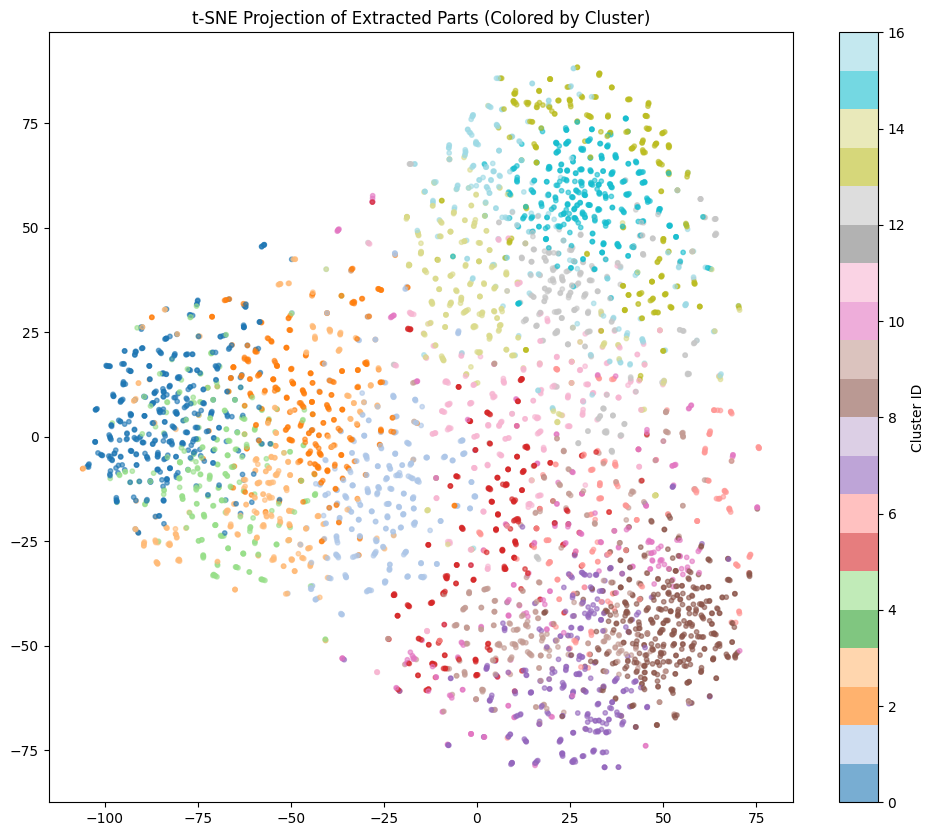


Visualizing clusters by class...

Computing t-SNE projection for per-class visualization...
Subsampling to 5000 points for visualization...
Skipping save to ../parts/clusters/tsne_by_class.png (Notebook mode)


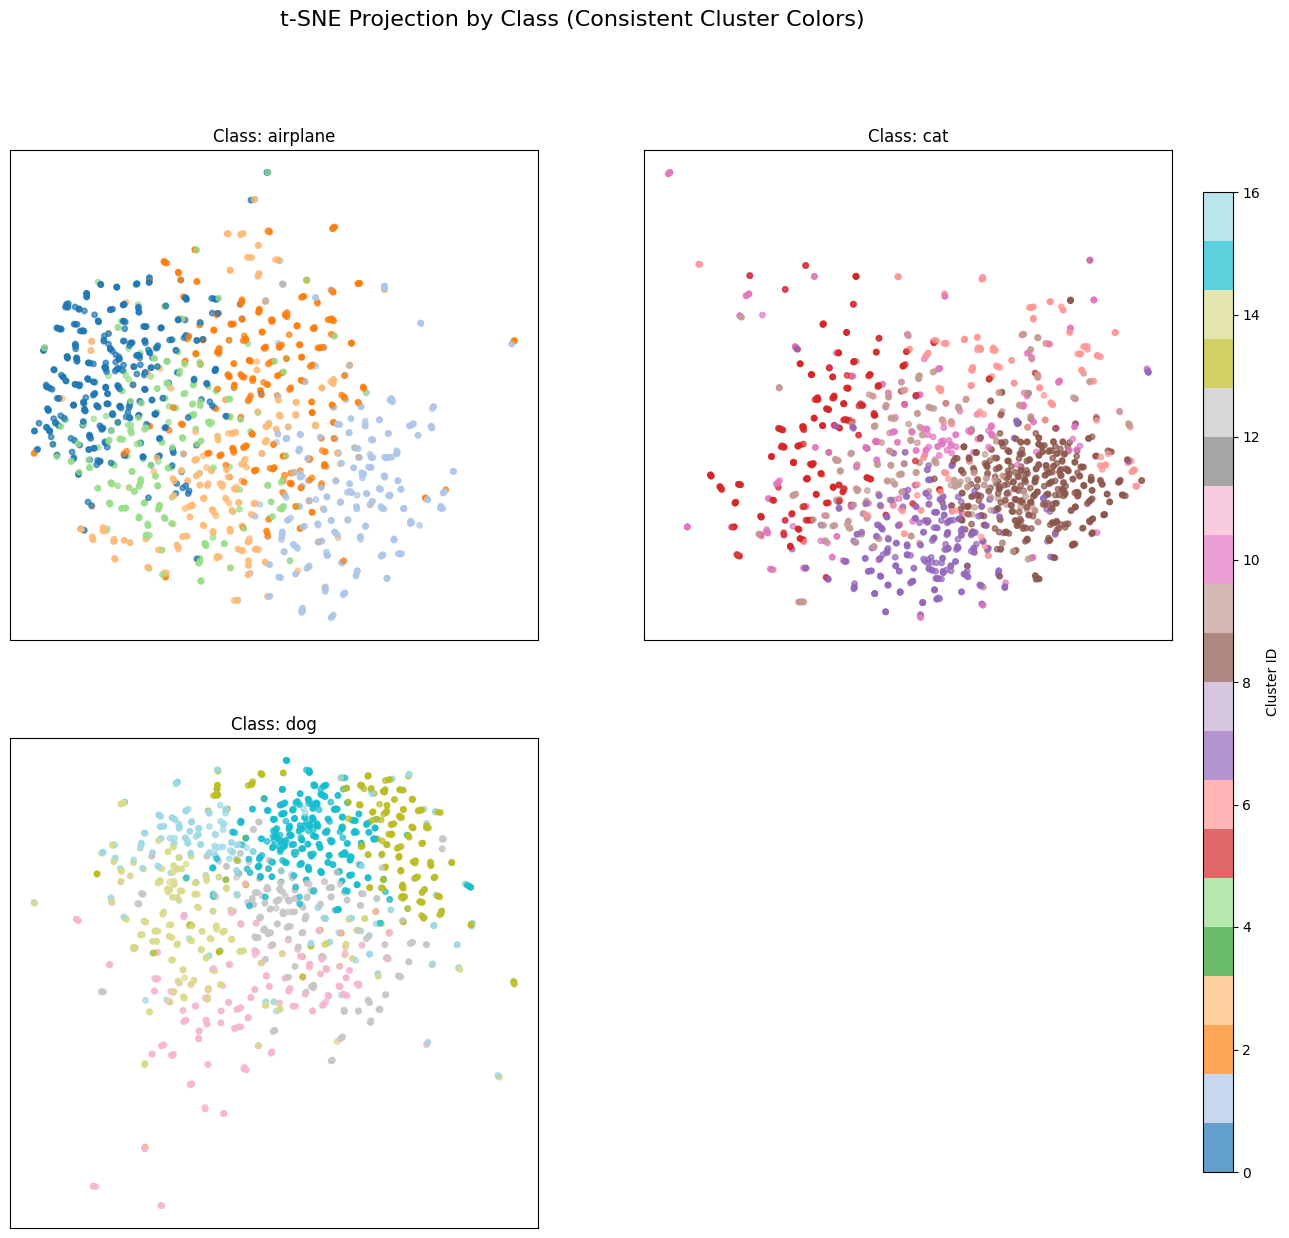

In [16]:
clusters_dir = Path(CLUSTERS_OUTPUT_DIR)
# Visualize clusters with t-SNE
print("Visualizing clusters...")
tsne_path = clusters_dir / 'tsne_projection.png'
visualize_clusters_tsne(
    features,
    cluster_labels,
    class_labels=part_to_class,
    save_path=tsne_path
)
plt.show()

# Visualize clusters by class (New)
print("\nVisualizing clusters by class...")
tsne_by_class_path = clusters_dir / 'tsne_by_class.png'
visualize_clusters_by_class(
    features,
    cluster_labels,
    class_labels=part_to_class,
    class_names=data_config['dataset']['classes'],
    save_path=tsne_by_class_path
)
plt.show()

---
## Step 3: Visualize Cluster Samples

View sample attention masks from specific clusters.

In [17]:
def visualize_cluster_samples(cluster_id, num_samples=10):
    """
    Visualize attention masks from a specific cluster
    """
    # Find parts in this cluster
    cluster_mask = cluster_labels == cluster_id
    part_indices = np.where(cluster_mask)[0]
    
    # Sample randomly
    if len(part_indices) > num_samples:
        sampled_indices = np.random.choice(part_indices, num_samples, replace=False)
    else:
        sampled_indices = part_indices
    
    # Get cluster statistics
    cluster_size = len(part_indices)
    cluster_classes = part_to_class[cluster_mask]
    unique_classes, counts = np.unique(cluster_classes, return_counts=True)
    
    print(f"Cluster {cluster_id}")
    print(f"  Size: {cluster_size} parts")
    print(f"  Class distribution:")
    for cls, count in zip(unique_classes, counts):
        pct = (count / len(cluster_classes)) * 100
        print(f"    {class_names[cls]:12s}: {pct:5.1f}% ({count} parts)")
    
    # Visualize samples
    cols = 5
    rows = (len(sampled_indices) + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    if rows == 1:
        axes = axes.reshape(1, -1)
    
    for idx, part_idx in enumerate(sampled_indices):
        row = idx // cols
        col = idx % cols
        
        image_idx = part_to_image[part_idx]
        slot_idx = part_to_slot[part_idx]
        class_idx = part_to_class[part_idx]
        
        mask = parts_data['masks'][image_idx, slot_idx]
        
        axes[row, col].imshow(mask, cmap='hot', interpolation='bilinear')
        axes[row, col].set_title(
            f"Img {image_idx}, Slot {slot_idx}\n{class_names[class_idx]}",
            fontsize=9
        )
        axes[row, col].axis('off')
    
    # Hide unused subplots
    for idx in range(len(sampled_indices), rows * cols):
        row = idx // cols
        col = idx % cols
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()

Cluster 0
  Size: 564 parts
  Class distribution:
    airplane    : 100.0% (564 parts)


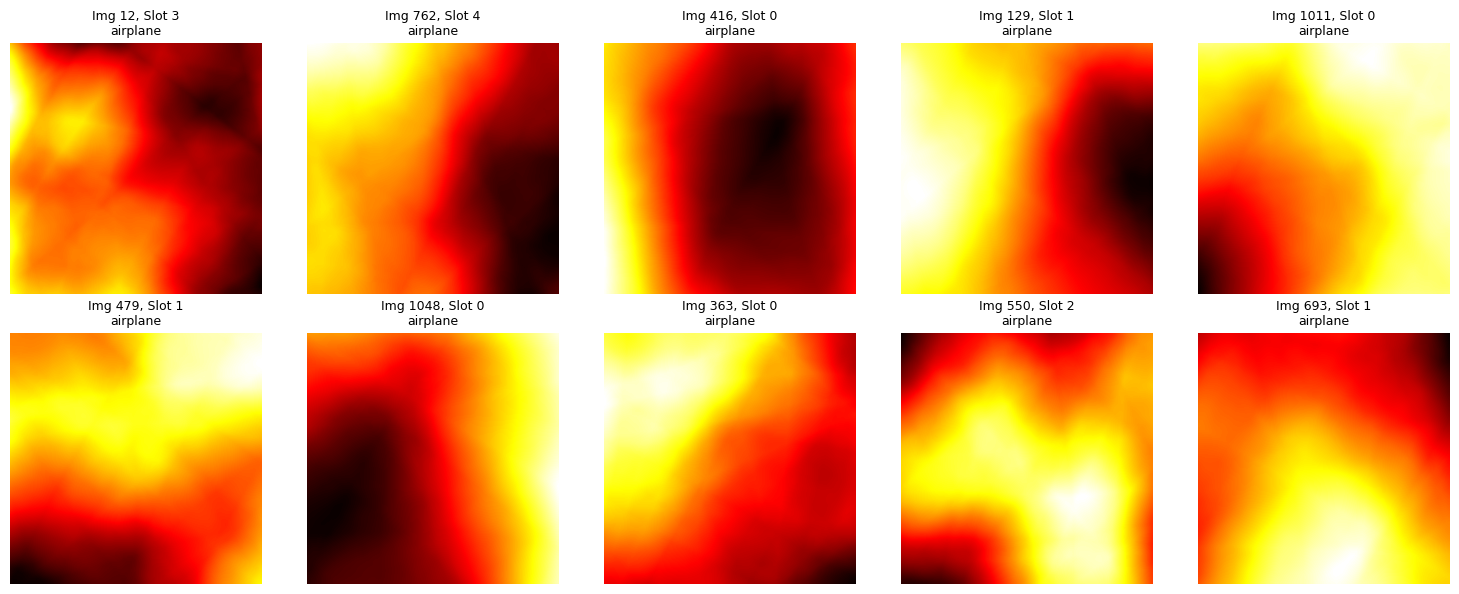

In [18]:
# Visualize samples from cluster 0
class_names = data_config['dataset']['classes']
visualize_cluster_samples(cluster_id=0, num_samples=10)


Cluster 0
  Size: 564 parts
  Class distribution:
    airplane    : 100.0% (564 parts)


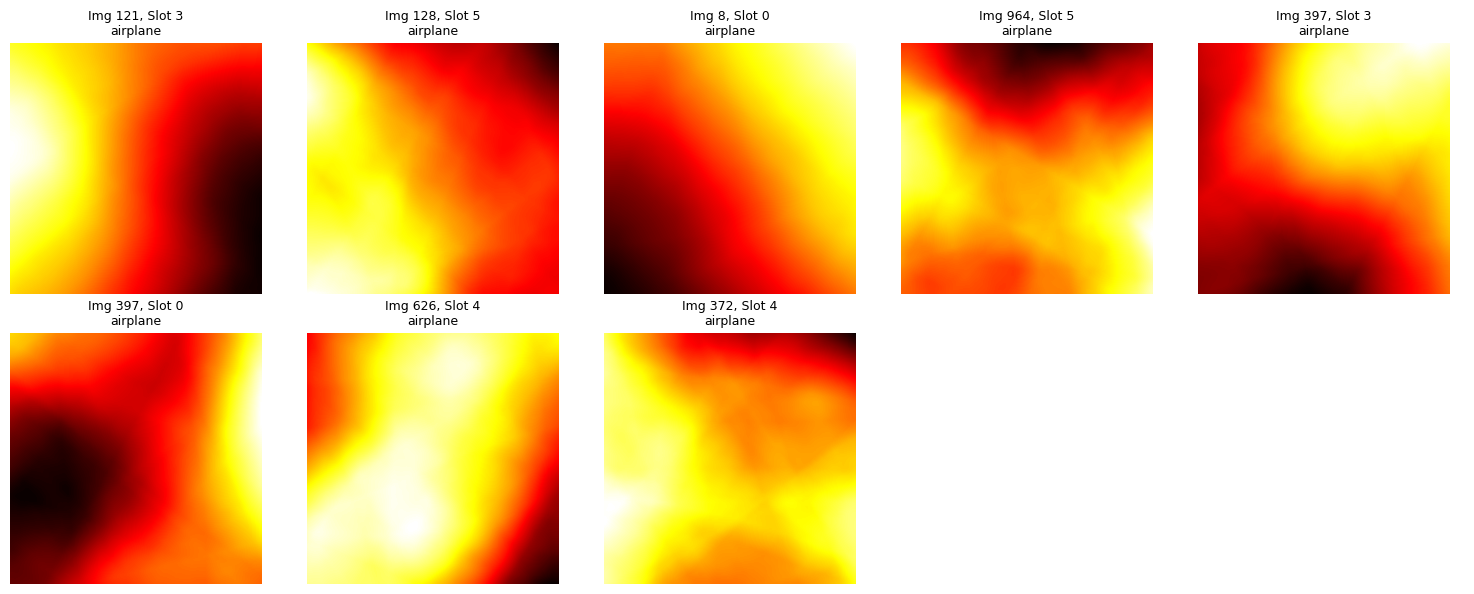


Cluster 1
  Size: 534 parts
  Class distribution:
    airplane    : 100.0% (534 parts)


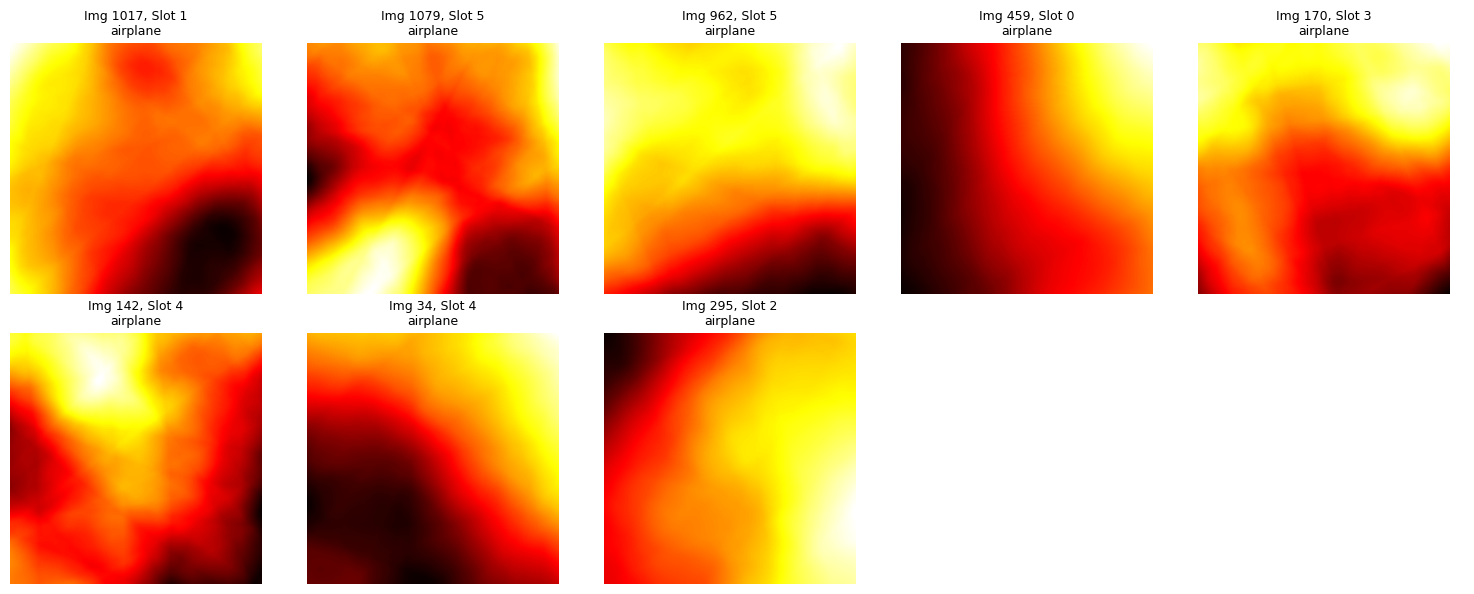


Cluster 2
  Size: 458 parts
  Class distribution:
    airplane    : 100.0% (458 parts)


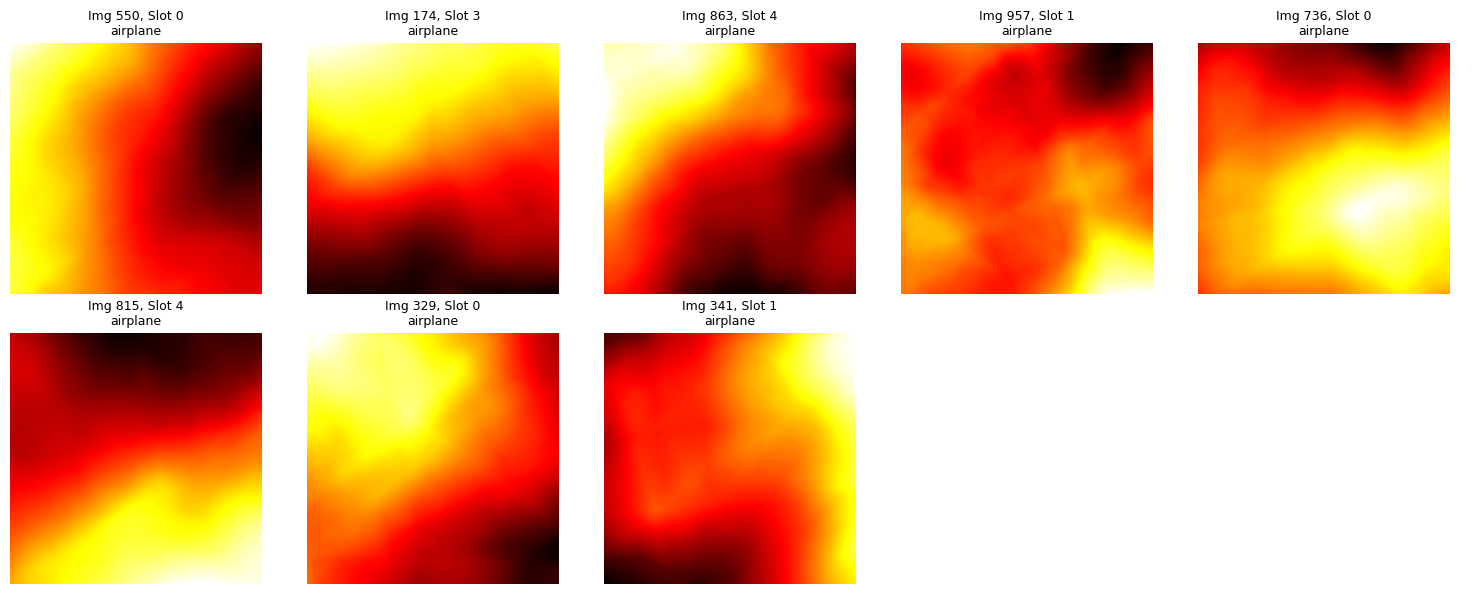

In [19]:
# Try different clusters (change the cluster_id)
for cluster_id in range(min(3, n_clusters)):  # Show first 3 clusters
    print(f"\n{'='*60}")
    visualize_cluster_samples(cluster_id=cluster_id, num_samples=8)

---
## Step 4: Summary Statistics

In [21]:
# Display overall statistics
print("="*70)
print("PHASE 2 PIPELINE SUMMARY")
print("="*70)

print(f"\n📊 Extraction:")
print(f"  Images processed: {len(parts_data['image_ids'])}")
print(f"  Slots per image: {parts_data['slots'].shape[1]}")
print(f"  Total parts: {features.shape[0]}")
print(f"  Checkpoint epoch: {checkpoint.get('epoch', 'N/A') if checkpoint else 'N/A'}")
print(f"  Checkpoint loss: {checkpoint.get('loss', 0) if checkpoint else 0:.4f}")

print(f"\n🎯 Clustering:")
print(f"  Number of clusters: {n_clusters}")
print(f"  Parts per cluster (avg): {len(cluster_labels) / n_clusters:.1f}")

# Cluster size distribution
unique_clusters, cluster_sizes = np.unique(cluster_labels, return_counts=True)
print(f"  Min cluster size: {cluster_sizes.min()}")
print(f"  Max cluster size: {cluster_sizes.max()}")
print(f"  Median cluster size: {np.median(cluster_sizes):.0f}")

print(f"\n📁 Output Directories:")
print(f"  Parts: {PARTS_OUTPUT_DIR}")
print(f"  Clusters: {CLUSTERS_OUTPUT_DIR}")

print(f"\n✅ Next Steps:")
print(f"  1. Review cluster visualizations above")
print(f"  2. Launch labeling interface:")
print(f"     streamlit run ../src/clustering/streamlit_labeler.py")
print(f"  3. After labeling, generate analysis:")
print(f"     python ../experiments/link_parts_to_classes.py")

print("\n" + "="*70)

PHASE 2 PIPELINE SUMMARY

📊 Extraction:
  Images processed: 1200
  Slots per image: 6
  Total parts: 7200
  Checkpoint epoch: N/A
  Checkpoint loss: 0.0000

🎯 Clustering:
  Number of clusters: 17
  Parts per cluster (avg): 423.5
  Min cluster size: 284
  Max cluster size: 597
  Median cluster size: 420

📁 Output Directories:
  Parts: ../parts/extracted
  Clusters: ../parts/clusters

✅ Next Steps:
  1. Review cluster visualizations above
  2. Launch labeling interface:
     streamlit run ../src/clustering/streamlit_labeler.py
  3. After labeling, generate analysis:
     python ../experiments/link_parts_to_classes.py



---
## Phase 2: Quick Cluster Analysis

Identify class-specific vs shared parts without semantic labels.

In [22]:
# Identify part types based on co-occurrence
threshold = 70  # % threshold for class-specific

class_specific = {cls: [] for cls in class_names}
shared_parts = []
background_parts = []

for cluster_id in range(n_clusters):
    max_pct = cooccurrence_matrix[cluster_id].max()
    max_class_idx = cooccurrence_matrix[cluster_id].argmax()
    significant_classes = (cooccurrence_matrix[cluster_id] > 20).sum()
    
    if max_pct >= threshold:
        class_specific[class_names[max_class_idx]].append(cluster_id)
    elif significant_classes >= 3:
        background_parts.append(cluster_id)
    else:
        shared_parts.append(cluster_id)

print("Part Type Analysis:\n")
print(f"Class-Specific Parts:")
for cls, clusters in class_specific.items():
    if clusters:
        print(f"  {cls:12s}: {len(clusters)} clusters - {clusters}")

print(f"\nShared Parts: {len(shared_parts)} clusters")
if shared_parts:
    print(f"  {shared_parts}")

print(f"\nBackground Parts: {len(background_parts)} clusters")
if background_parts:
    print(f"  {background_parts}")

Part Type Analysis:

Class-Specific Parts:
  airplane    : 5 clusters - [0, 1, 2, 3, 4]
  cat         : 6 clusters - [5, 6, 7, 8, 9, 10]
  dog         : 6 clusters - [11, 12, 13, 14, 15, 16]

Shared Parts: 0 clusters

Background Parts: 0 clusters


---
## 🎉 Pipeline Complete!

You've successfully:
1. ✅ Extracted parts from trained Slot Attention model
2. ✅ Clustered parts with optimal K selection
3. ✅ Visualized clusters and analyzed quality metrics
4. ✅ Analyzed cluster-class correlations

**Next Steps:**
- Use the Streamlit interface to assign semantic labels
- Generate final interpretability report
- Use findings for your research paper!

## Phase 3: Classification with Discovered Parts

We now validate the semantic quality of our discovered parts by using them to classify images.
We treat the discovered clusters as a "Visual Vocabulary". For each image, we build a histogram of its parts (Bag-of-Visual-Words) and train a simple linear classifier to predict the object class.

High classification accuracy indicates that the unsupervised parts are consistent and discriminative features.

Loading clustering results from: ../parts/clusters
Constructing Bag-of-Words histograms for 1200 images...
Vocabulary size (Number of Clusters): 17

Data Split:
  Train size: 960
  Test size:  240

Training Neural Network Classifier (MLP)...

Test Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

    airplane       1.00      1.00      1.00        80
         cat       1.00      1.00      1.00        80
         dog       1.00      1.00      1.00        80

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240

Skipping save to ../parts/classification/confusion_matrix.png (Notebook mode)


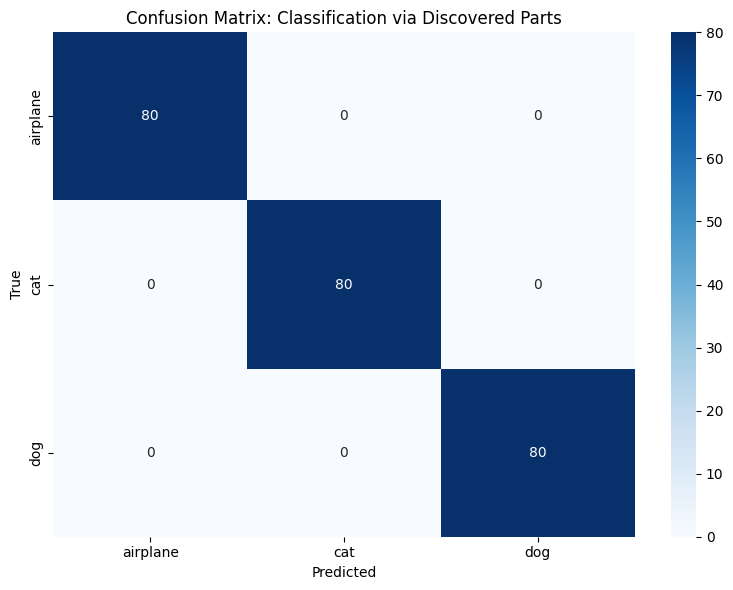


Classification Confusion Matrix:


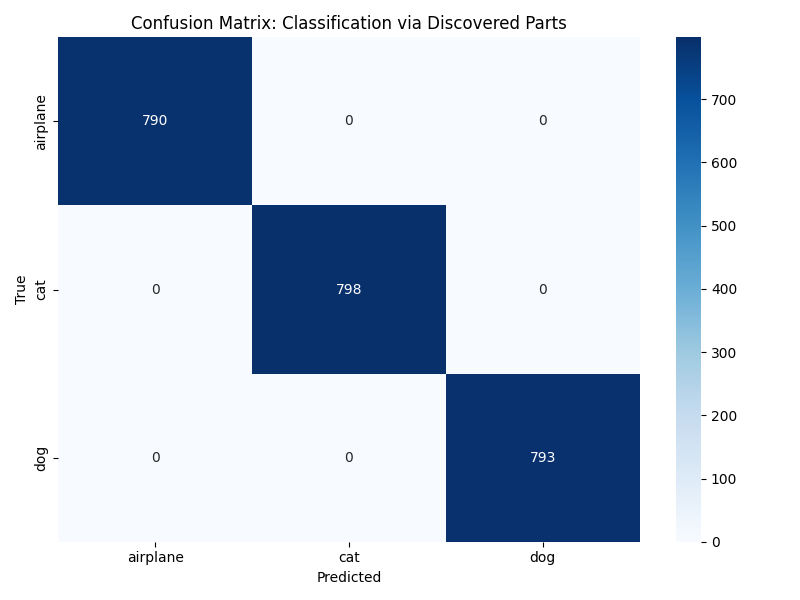

In [24]:
# Import classification functions
from experiments.classify_with_parts import (
    load_clustering_results,
    compute_image_histograms,
    train_and_evaluate,
    plot_confusion_matrix
)
from pathlib import Path
from IPython.display import Image, display

# Configuration
clusters_dir = Path('../parts/clusters')
output_dir = Path('../parts/classification')
output_dir.mkdir(parents=True, exist_ok=True)

# 1. Load Data
data = load_clustering_results(clusters_dir)
class_names = data['metadata']['classes']

# 2. Compute Histograms (Features)
X, y = compute_image_histograms(data)

# 3. Train and Evaluate
clf, y_test, y_pred = train_and_evaluate(X, y, class_names)

# 4. Visualize
plot_confusion_matrix(y_test, y_pred, class_names, output_dir / 'confusion_matrix.png')

# Display Result
print("\nClassification Confusion Matrix:")
display(Image(filename=output_dir / 'confusion_matrix.png'))